# Variational Autoencoders - Zero to Hero

![vae](vae.jpg)

Variational Autoencoders (VAEs) are a classic image generation technique. This post traces a path from simple probabilistic reasoning to VAEs. We build up the theory from Maximum Likelihood Estimation through the Expectation-Maximization (EM) algorithm, then apply these ideas to train a conditional VAE that can generate faces from simple text prompts.

## 1. Maximum Likelihood Estimation

Let's start with a simple problem. We have a coin with unknown bias $\theta$ (probability of heads). We flip it $n$ times and observe $h$ heads. Here, $x = (n,h)$ is called the data and $\theta$ is called the parameter.
Since each coin toss is independent, the probability of this set of outcomes is:

$$
p(x|\theta) = \theta^h (1 - \theta)^{n-h}
$$

How can we use this to find the most $likely$ value of $\theta$? Intuitively, it should be the one that maximizes the probability of the observed data, $p(x|\theta)$. So we reinterpret $p(x|\theta)$ as $L(\theta)$, called the likelihood. This gives us the maximum likelihood estimate (MLE).

**Example:** With 7 heads in 10 flips, we have $L(\theta) = \theta^7 (1-\theta)^3$.
To maximize $L(\theta)$, we take the log (for easier differentiation) and set the derivative to zero:

$$
\ell(\theta) = h \log \theta + (n-h) \log(1-\theta) \\
\Rightarrow \frac{d\ell}{d\theta} = \frac{h}{\theta} - \frac{n-h}{1-\theta} = 0
$$

Solving:

$$
\begin{align*}
\hat{\theta}_{MLE} = \frac{h}{n} \\
\end{align*}
$$

The MLE in this case is simply the observed fraction of heads: $\hat{\theta}_{MLE} = h/n$.

Let's simulate $n=10,000$ coin tosses below.

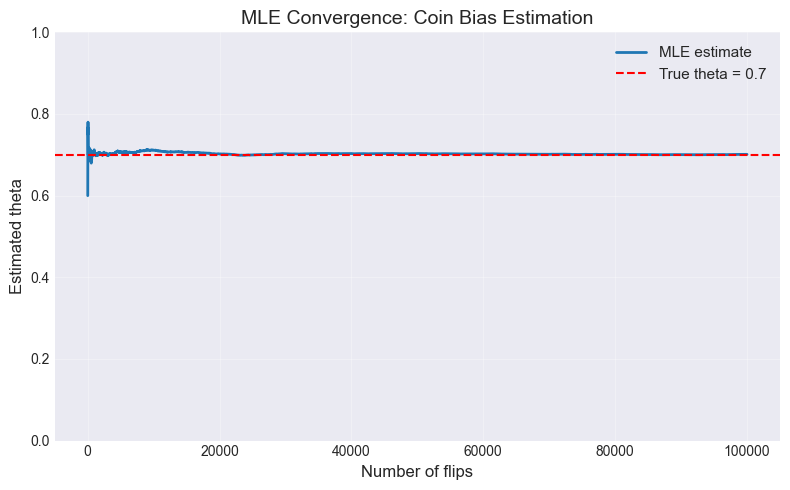

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
# Set random seed for reproducibility
np.random.seed(42)

# True coin bias (unknown in practice, known here for demonstration)
true_theta = 0.7

# Simulate coin flips
n_flips = 100000
coin_flips = np.random.binomial(1, true_theta, n_flips)

# MLE estimate: fraction of heads
n_heads = np.sum(coin_flips)
theta_mle = n_heads / n_flips

# Visualize convergence as we get more data
theta_estimates = []
sample_sizes = range(10, n_flips + 1, 10)

for n in sample_sizes:
    partial_flips = coin_flips[:n]
    theta_est = np.sum(partial_flips) / n
    theta_estimates.append(theta_est)

# Plot convergence
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, theta_estimates, label='MLE estimate', linewidth=2)
plt.axhline(y=true_theta, color='r', linestyle='--', label=f'True theta = {true_theta}')
plt.xlabel('Number of flips', fontsize=12)
plt.ylabel('Estimated theta', fontsize=12)
plt.title('MLE Convergence: Coin Bias Estimation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



Notice how the estimate gets more accurate with the number of flips. Next, let's plot the log-likelihood function for different values of $\theta$.

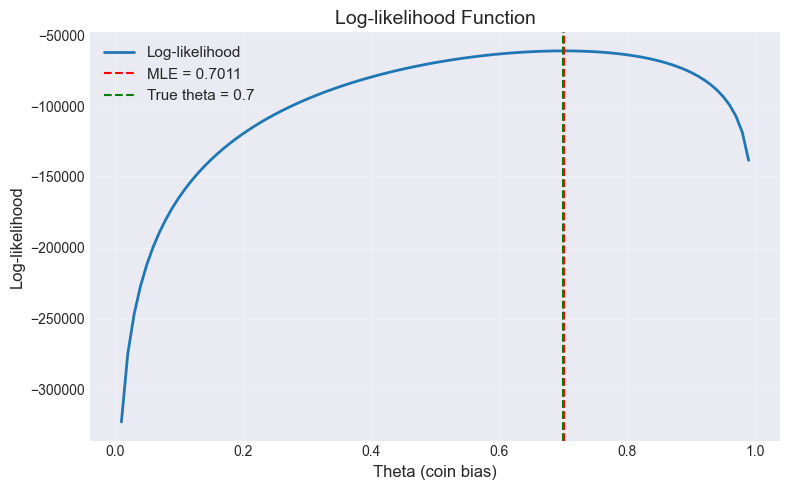

In [11]:
# Likelihood function visualization
theta_range = np.linspace(0.01, 0.99, 100)
log_likelihoods = []

for theta in theta_range:
    # Log-likelihood: h*log(theta) + (n-h)*log(1-theta)
    log_likelihood = n_heads * np.log(theta) + (n_flips - n_heads) * np.log(1 - theta)
    log_likelihoods.append(log_likelihood)

# Plot likelihood
plt.figure(figsize=(8, 5))
plt.plot(theta_range, log_likelihoods, linewidth=2, label='Log-likelihood')
plt.axvline(x=theta_mle, color='r', linestyle='--', label=f'MLE = {theta_mle:.4f}')
plt.axvline(x=true_theta, color='g', linestyle='--', label=f'True theta = {true_theta}')
plt.xlabel('Theta (coin bias)', fontsize=12)
plt.ylabel('Log-likelihood', fontsize=12)
plt.title('Log-likelihood Function', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Notice how the maxima of the log-likelihood is at the true $\theta$.

## 2. Inference with Known Parameters

Now we flip the setup: the parameter $\theta$ is known, but some data is hidden. Suppose we flipped the coin $n$ times, but $k$ outcomes are missing. We observed $h_{obs}$ heads in the $n-k$ observed flips. The $k$ missing flips are called latent variables $z$.

We want the distribution of the missing flips given what we observed: $p(z | x_{obs}, \theta)$. In general, this could depend on the observed data. However, coin flips are independent i.e each toss doesn't affect the others. So the missing flips follow the same distribution regardless of what we observed: $p(z | x_{obs}, \theta) = p(z | \theta)$.

The number of heads among the $k$ missing flips follows a Binomial distribution:

$$p(i \text{ heads in missing} | \theta) = \binom{k}{i} \theta^i (1-\theta)^{k-i}$$

We can compute the expected value:

$$\mathbb{E}[\text{heads in missing}] = k \cdot \theta$$

We substitute this expected value in place of the actual (unknown) count.

## 3. Two Biased Coins

So far we've worked with a single observation (one sequence of coin flips). Now consider a dataset with multiple observations.

Imagine we have $N$ sequences of coin flips. For each sequence $i$, we observe $(n_i, h_i)$ number of flips and the number of heads. But there's a twist: we have two biased coins, and we don't know which coin was used for each sequence.

This gives us:
- **Observed data:** $x_i = (n_i, h_i)$ for each sequence $i = 1, \ldots, N$
- **Latent variable:** $z_i \in \{1, 2\}$ indicating which coin was used for sequence $i$
- **Parameters:** $\theta_1, \theta_2$ (coin biases) and $\pi$ (probability of using coin 1)

**Case 1**: We know which coin was used for each sequence.
When the latent variable $z_i$ is observed, this reduces to two separate single-coin problems. For coin 1:

$$\hat{\theta}_1 = \frac{\sum_{i: z_i=1} h_i}{\sum_{i: z_i=1} n_i}$$

This is just MLE applied separately to each coin's data. Simple and tractable.

**Case 2**: We know the coin biases but not which coin was used.
Here we compute the posterior over the latent $z_i$ using Bayes' rule:

$$p(z_i | x_i, \theta) = \frac{p(x_i | z_i, \theta) p(z_i)}{p(x_i | \theta)}$$

Substituting the specific distributions:

$$p(z_i = 1 | x_i, \theta) = \frac{\pi \cdot \theta_1^{h_i} (1-\theta_1)^{n_i-h_i}}{\pi \cdot \theta_1^{h_i} (1-\theta_1)^{n_i-h_i} + (1-\pi) \cdot \theta_2^{h_i} (1-\theta_2)^{n_i-h_i}}$$

We can now infer which coin was likely used for each sequence. If $p(z_i = 1 | x_i, \theta) > 0.5$, sequence $i$ most likely came from coin 1; otherwise, coin 2.

**Case 3**: Neither the coin biases nor which coin was used is known.
This is where things get interesting. We have a chicken-and-egg problem. To estimate the coin biases ($\theta_1, \theta_2$), we need to know which sequences came from which coin. Conversely, to determine which coin generated each sequence, we need to know the coin biases.

What if we alternated between these two easy problems?
1. Start with a guess for the parameters (say, $\theta_1^{(0)} = 0.6$, $\theta_2^{(0)} = 0.4$, $\pi^{(0)} = 0.5$).
2. Compute the posterior probability $p(z_i=1|x_i, \theta^{(t)})$ that each sequence came from coin 1.
3. Using our posterior probabilities as "soft" assignments), update the parameters via weighted MLE.
4. Repeat until convergence.

This alternation is the essence of Expectation-Maximization. The E-step fills in what we don't know (which coin was used) using our current best guess; the M-step updates our guess using the filled-in data.  Each iteration improves our estimate. The E-step gives us the best possible probabilistic completion of the missing data given our current parameters; the M-step finds the best parameters given that completion. We're never fully correct, but we're always getting better.

We have three parameters to estimate: $\theta = (\theta_1, \theta_2, \pi)$, where $\pi$ is the probability of selecting coin 1.

**E-step:** Compute the posterior probability that sequence $i$ came from coin 1, given current parameters $\theta^{(t)}$:

$$w_i^{(t)} = p(z_i = 1 | x_i, \theta^{(t)}) = \frac{\pi^{(t)} \cdot (\theta_1^{(t)})^{h_i} (1-\theta_1^{(t)})^{n_i-h_i}}{\pi^{(t)} \cdot (\theta_1^{(t)})^{h_i} (1-\theta_1^{(t)})^{n_i-h_i} + (1-\pi^{(t)}) \cdot (\theta_2^{(t)})^{h_i} (1-\theta_2^{(t)})^{n_i-h_i}}$$

**M-step:** Update parameters by maximizing the expected complete-data log-likelihood:

$$Q(\theta, \theta^{(t)}) = \mathbb{E}_{p(z|x, \theta^{(t)})}[\log p(x, z | \theta)]$$

If we knew which coin was used for each sequence, the complete-data log-likelihood would be:

$$\log p(x, z | \theta) = \sum_i \left[ \mathbb{1}(z_i=1) \log(\pi \cdot p(x_i|z_i=1, \theta)) + \mathbb{1}(z_i=2) \log((1-\pi) \cdot p(x_i|z_i=2, \theta)) \right]$$

Since we don't know $z_i$, we substitute our posterior beliefs $w_i^{(t)}$ as the expected values of $\mathbb{1}(z_i=1)$:

$$Q(\theta, \theta^{(t)}) = \sum_i \left[ w_i^{(t)} \log(\pi \cdot p(x_i|z_i=1, \theta)) + (1-w_i^{(t)}) \log((1-\pi) \cdot p(x_i|z_i=2, \theta)) \right]$$

You might wonder why maximizing the expected complete-data log-likelihood helps us maximize the marginal likelihood $p(x|\theta)$ — which is what we actually want. Remarkably, this alternation guarantees the marginal likelihood never decreases. The theoretical justification involves the ELBO, which we'll explore after introducing the Variational Autoencoder. For now, trust that this weighted counting procedure climbs toward the maximum likelihood solution..

The resulting update rules are intuitive weighted averages:

$$\theta_1^{(t+1)} = \frac{\sum_i w_i^{(t)} \cdot h_i}{\sum_i w_i^{(t)} \cdot n_i}, \quad \theta_2^{(t+1)} = \frac{\sum_i (1 - w_i^{(t)}) \cdot h_i}{\sum_i (1 - w_i^{(t)}) \cdot n_i}, \quad \pi^{(t+1)} = \frac{1}{N} \sum_i w_i^{(t)}$$

Each iteration is guaranteed to increase (or maintain) the marginal likelihood of the observed data.

## 4. From Inference to Generation

So far we've focused on inference: given observed data, estimate unknown parameters or latents. But there's another crucial capability: generation i.e. creating new data that looks like it came from the same distribution as our training data. In the two-coin setting, this means generating new sequences of flips that could plausibly have come from our two-coin system.

1. Sample the latent: Choose which coin to use.
   $$z \sim \text{Bernoulli}(\pi)$$
   - With probability $\pi$, select coin 1.
   - With probability $1-\pi$, select coin 2.

2. Sample the data: Flip the selected coin $n$ times.
   - If $z = 1$: $h \sim \text{Binomial}(n, \theta_1)$.
   - If $z = 2$: $h \sim \text{Binomial}(n, \theta_2)$.

This is the generative process defined by $p(x, z) = p(x|z)p(z)$. The latent $z$ provides structure; the conditional $p(x|z)$ generates the actual data.

- Inference ($p(z|x)$): "Given this sequence, which coin was probably used?"
- Generation ($p(x|z)p(z)$): "Create a new sequence by first choosing a coin, then flipping it"

This duality is the foundation of generative modeling. The latents $z$ provide a compact representation that captures the essential structure of the data, enabling both understanding and synthesis.

## 5. The Curse of Dimensionality

The classical EM algorithm works beautifully for the two-coin problem because the E-step is tractable — we can compute $p(z|x, \theta)$ in closed form using Bayes' rule and the M-step has a simple closed-form solution — weighted averages for the parameters. But what happens with many possible latent values?

The two-coin problem works because $z_i$ has only 2 possible values. The E-step just computes:

$$p(z_i=1|x_i, \theta) = \frac{p(x_i|z_i=1,\theta) \cdot \pi}{p(x_i|z_i=1,\theta) \cdot \pi + p(x_i|z_i=2,\theta) \cdot (1-\pi)}$$

What if we had 100 coins instead? Now $z_i \in \{1, 2, \ldots, 100\}$. The E-step requires:

$$p(z_i=k|x_i, \theta) = \frac{p(x_i|z_i=k, \theta) \cdot p(z_i=k)}{\sum_{j=1}^{100} p(x_i|z_i=j, \theta) \cdot p(z_i=j)}$$

The denominator sums over all 100 possible coins. This is still tractable, but much slower. With 1,000 sequences and 100 coins, we're doing 100,000 evaluations per E-step.

As the number of latent possibilities grows, the E-step becomes increasingly expensive. The denominator in Bayes' rule requires summing over all possible values of $z$. With continuous latents, this sum becomes an integral over infinite space.

We need a smarter approach — one that works when we can't compute the exact posterior.

## 6. From Simple to Complex Distributions — Why We Need Neural Networks

The two-coin model works because the data is simple: we can describe the entire distribution with just three numbers ($\theta_1, \theta_2, \pi$). Sampling is straightforward because we know exactly how to sample from Bernoulli and Binomial distributions. But what about images?

Consider generating a 28×28 grayscale image (like MNIST). There are $256^{784}$ possible images — an astronomically large space. The distribution over "images that look like handwritten digits" is incredibly complex. Each pixel depends on its neighbors in complex, non-linear ways. The data contains multiple distinct classes (digits 0-9), each with its own structure. Hence, $p(x)$ has no closed-form expression.

Neural networks can learn to approximate complex functions. Instead of manually specifying $p(x|z)$, we can learn it. A neural decoder $x = f_\theta(z)$ — maps a simple latent code $z$ to a complex image $x$. The same architecture can learn to generate faces, bedrooms, or handwritten digits — just train on different data.

## 7. Autoencoders — Learning to Compress and Reconstruct

An autoencoder learns to compress data into a compact representation and then reconstruct the original from that compression. The architecture consists of two parts:
- **Encoder:** Maps input to a latent code $z = f_{\text{enc}}(x)$
- **Decoder:** Reconstructs input from the latent code $\hat{x} = f_{\text{dec}}(z)$

We train the autoencoder to minimize reconstruction error—typically MSE between input and output. The model learns to preserve only the information needed for reconstruction, discarding noise and redundancy.

Our implementation uses three convolutional layers with stride-2 downsampling in the encoder, producing a 16-dimensional latent code. The decoder uses three transposed convolutions to upsample back to a 56×56 RGB image.

Let's train this autoencoder on the Celeb-A dataset, which contains over 200,000 celebrity images.

While autoencoders excel at reconstruction, they cannot generate new images:
- The encoder maps training images to latent points, but these points occupy an irregular, non-continuous region of the latent space. Some areas encode valid images; others encode gibberish.

- To generate, we need to sample latent codes that decode to valid images. But we have no knowledge of *which* points produce valid outputs—the encoder only defines mappings for training examples.

- Interpolating between two training points in latent space often produces nonsensical outputs because the latent space lacks smooth structure.

In our implementation, we sample random latent vectors from a standard normal distribution and pass them through the decoder. The random latents fall in regions of the latent space that the decoder never learned to interpret during training.  We need a probabilistic framework that structures the latent space so sampling works.

## 8. The Variational Autoencoder

The Variational Autoencoder solves the autoencoder's sampling problem by treating the latent representation probabilistically. Instead of encoding to a single point, the encoder outputs a distribution over latents. The Decoder maps from latent space to data space: $p_\theta(x|z)$

We can interpret the VAE through the lens of the EM algorithm from Section 3. Recall that the E-step requires the posterior $p(z|x)$ — the distribution of latents given the observed data. For the coin problem, we computed this exactly using Bayes' rule. For neural networks, the true posterior is intractable because the denominator $p(x) = \int p(x|z)p(z)dz$ has no closed form. The encoder serves as an approximation $q(z|x) \approx p(z|x)$.

## 9. The Evidence Lower Bound (ELBO) — A General Framework for Approximate Inference

The EM algorithm we used in Section 3 is a special case of a more general framework called variational inference. This framework becomes essential when we can't compute the exact posterior $p(z|x)$. Instead of using the true posterior, introduce an approximate distribution $q(z)$ and optimize it to be as close as possible to $p(z|x)$, which neatly maps onto the encoder of our VAE model.

For any distribution $q(z)$, we can decompose the log marginal likelihood:

$$\log p(x) = \underbrace{\mathbb{E}_q[\log p(x, z)] - \mathbb{E}_q[\log q(z)]}_{\text{ELBO}(q)} + \underbrace{D_{KL}(q(z) \| p(z|x))}_{\text{gap}}$$

This is the Evidence Lower Bound (ELBO). It decomposes into:
1. **Expected complete-data log-likelihood:** How well $q(z)$ explains the data.
2. **Negative entropy:** Regularization that prevents $q(z)$ from becoming too concentrated.
3. **KL divergence gap:** The difference between our approximation and the true posterior.

**Key properties:**
- **Lower bound:** $\text{ELBO}(q) \leq \log p(x)$ because KL $\geq 0$.
- **Tractable:** We can compute and optimize it without marginalizing over all latents.
- **Tight when:** $q(z) = p(z|x)$ makes KL = 0, so $\text{ELBO} = \log p(x)$.

## 10. Joint Optimization with Neural Networks

**The neural network encoder:**

$$q_\phi(z|x) = \mathcal{N}(z; \mu_\phi(x), \sigma_\phi^2(x))$$

The encoder learns to predict:
- $\mu_\phi(x)$: which latent codes are likely for this image
- $\sigma_\phi(x)$: how uncertain we are about those latents

Instead of alternating E and M steps, we train both networks simultaneously:
- Forward pass: Encoder produces $q(z|x)$, decoder computes $p(x|z)$
- Compute ELBO (reconstruction term + KL term)
- Backpropagate gradients to both encoder $\phi$ and decoder $\theta$
- Update both with gradient descent.

Each training step makes small improvements to both networks. The encoder learns to produce better approximate posteriors; the decoder learns to generate better reconstructions. They co-evolve during training.

**The reparameterization trick:** To backpropagate through the sampling operation $z \sim q(z|x)$, we use:

$$z = \mu_\phi(x) + \sigma_\phi(x) \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

This moves the randomness outside the computation graph, allowing gradients to flow through $\mu$ and $\sigma$.

## 11. Two Views of the Same Algorithm

The ELBO framework unifies different approaches. Let's see how it applies to our two scenarios:

**View 1: Two-Coin Problem (Exact Posterior Available)**

When we CAN compute $p(z|x)$ exactly (like with two coins), we set $q(z) = p(z|x, \theta^{(t)})$:
- **E-step:** KL gap becomes zero, giving the tightest bound.
- **M-step:** Maximize $\mathbb{E}_q[\log p(x, z | \theta)]$ — this is exactly the classical EM from Section 3.

**View 2: Neural Networks (Exact Posterior Intractable)**

When we CAN'T compute $p(z|x)$ (like with neural networks), we use a neural network to approximate it:
- **Encoder:** $q_\phi(z|x) \approx p(z|x)$ — learned approximation.
- **Joint optimization:** Update both $\phi$ (encoder) and $\theta$ (decoder) using gradient descent on the ELBO.
- The KL gap is non-zero but we minimize it during training.

**The connection:** Classical EM is coordinate ascent on the ELBO when the exact posterior is available. Neural network VAEs use the same ELBO objective but with a learned approximate posterior.

## 12. A Simple VAE

We train a VAE on the CelebA dataset (56×56 face images). The encoder uses three convolutional layers with stride-2 downsampling to extract features, followed by a linear layer that outputs a 16-dimensional latent distribution (mean and log-variance). The decoder reverses this: a linear projection expands the latent code to spatial features, then three transposed convolutions upsample back to a 56×56 RGB image.

**The training objective:** The encoder approximates the true posterior $p(z|x)$ with $q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))$. We cannot maximize the marginal likelihood directly because $p(x) = \int p(x|z)p(z)dz$ is intractable. Instead, we maximize a lower bound (ELBO):

$$\log p(x) = \underbrace{\mathbb{E}_{q_\phi}[\log p(x|z)] - D_{KL}(q_\phi(z|x) \| p(z))}_{\text{ELBO}} + \underbrace{D_{KL}(q_\phi(z|x) \| p(z|x))}_{\geq 0}$$

The gap is the KL divergence between our approximate posterior and the true posterior. Since KL $\geq 0$, the ELBO is a lower bound. Maximizing the ELBO tightens this bound while improving reconstruction. The KL term $D_{KL}(q_\phi \| p(z))$ regularizes our approximate posterior toward the prior $\mathcal{N}(0,I)$.

**The reparameterization trick:** To backpropagate through the sampling operation $z \sim q(z|x)$, we rewrite it as:

$$z = \mu_\phi(x) + \sigma_\phi(x) \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

The randomness moves outside the computation graph (to $\epsilon$), allowing gradients to flow through $\mu$ and $\sigma$. We sample $\epsilon$ from a standard normal, scale it by the learned standard deviation, shift by the learned mean, and get our latent code — all differentiable operations.

**The KL divergence term:** For a Gaussian approximate posterior $q_\phi(z|x) = \mathcal{N}(\mu, \text{diag}(\sigma^2))$ and standard normal prior $p(z) = \mathcal{N}(0, I)$, the KL divergence has a closed-form solution:

$$D_{KL}(q_\phi(z|x) \| p(z)) = \frac{1}{2} \sum_{j=1}^{J} \left( \sigma_j^2 + \mu_j^2 - \log \sigma_j^2 - 1 \right)$$

This term penalizes deviations from the prior. If the encoder outputs $\mu = 0$ and $\sigma = 1$ for all dimensions, the KL term equals zero. As the posterior drifts from the prior, the KL term increases, pushing the encoder to keep latent codes close to the standard normal distribution while still allowing enough flexibility for reconstruction.

**What the KL term enforces geometrically:**

The KL divergence forces the latent space to resemble a **spherical Gaussian centered at the origin**:

- **Centered**: The $\mu_j^2$ term pulls all encodings toward $z = 0$
- **Unit variance**: The $\sigma_j^2 - \log \sigma_j^2$ terms keep spread around $\sigma \approx 1$ in all directions.
- **Isotropic**: No preferred direction — the prior treats all dimensions equally.

**The tension:** The encoder wants to place each image's latent far from others to make reconstruction easy. The KL term pulls all latents toward the origin. The compromise creates a "fuzzy ball" in latent space where points are spread out but stay within a few standard deviations of zero. This structure ensures any random sample from the prior decodes to a valid face, and interpolation between points produces coherent intermediate images.

The generation results are starting to somewhat resemble faces now.

## 13. Conditioning the VAE: Text-Guided Generation

Unconditional VAEs sample random faces from $p(x)$ with no control over attributes. To generate specific types of images — a smiling person, someone with glasses — we need conditional generation: learning $p(x|c)$ where $c$ is a conditioning signal.

We use **FiLM (Feature-wise Linear Modulation)** to inject conditioning into the decoder. FiLM modulates feature maps using learned affine transformations derived from the conditioning signal:

$$\text{FiLM}(x | c) = \gamma(c) \odot x + \beta(c)$$

where $\gamma(c)$ and $\beta(c)$ are scale and shift vectors predicted from the CLIP embedding $c$ via small linear networks, and $\odot$ denotes element-wise multiplication. This allows the conditioning to amplify relevant feature channels (via scaling) and adjust activation levels (via shifting) at each decoder layer.

**CLIP** provides the conditioning vectors. This pre-trained model embeds both text and images into the same 512-dimensional space — a smiling face and the text "smiling person" map to nearby vectors. CLIP remains frozen during training; it acts as a fixed feature extractor.

The conditional ELBO becomes:

$$\mathcal{L}(\theta, \phi; x, c) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x | z, c)] - D_{\text{KL}}(q_\phi(z|x) \| p(z))$$

During training, we extract CLIP image embeddings for each training image and pass them through the FiLM layers in the decoder. The VAE learns to associate CLIP embedding directions with visual attributes. At inference, we encode text prompts through CLIP and generate images conditioned on those embeddings.